# Домашнее задание 1. Знакомство с API
Студент: __Соловьев Егор Николаевич, М08-501НД, 28.03.2026__

Задание выполняется в рамках модуля 1 «Проектирование API». Вы закрепите навыки разработки API, используя подход API-first.

> Чтобы получить максимальный балл, убедитесь, что ваш ноутбук запускается с нуля, структура понятна, а в выводах вы объясняете свои решения.  

## Подготовка окружения

In [1]:
!pip install requests -qqq

### Задание 1. Создать CRUD на основе встроенного HTTP сервера Python

Задача: создать сервер, который будет содержать код API с двумя методами HTTP.

*Здесь мы **специально** берем сильно устаревшую версию веб-сервера, написанную во времена Python 2.0 в 2000 году. Обратите внимание на многословность кода веб-сервера.*


In [2]:
import pandas as pd
import datetime

df = pd.DataFrame([
    ['Антифриз EURO G11 (-45°С) зеленый, силикатный 5кг', 1025, 329, 11, 'c', 'антифриз', datetime.datetime(2026, 10, 16, 12, 36, 22)],
    ['Антифриз готовый фиолетовый Синтек MULTIFREEZE 5кг', 250, 315, 38, 'b', 'антифриз', datetime.datetime(2025, 12, 11, 8, 25, 31)],
    ['Антифриз G11 зеленый', 120, 329, 61, 'b', 'антифриз', datetime.datetime(2025, 6, 15, 15, 36, 30)],
    ['Антифриз Antifreeze OEM China OAT red -40 5кг', 390, 504, 65, 'c', 'антифриз', datetime.datetime(2025, 11, 30, 4, 12, 39)],
    ['Антифриз G11 зеленый', 135, 407, 93, 'b', 'антифриз', datetime.datetime(2026, 8, 25, 3, 24, 1)],
])

df.columns = ['Наименование товара', 'Цена, руб.', 'cpm', 'Скидка', 'tp', 'Категория', 'dt']
df['Год'] = df['dt'].dt.year
df=df.drop(['cpm',  'tp', 'dt'],axis=1)
display(df)


,Наименование товара,"Цена, руб.",Скидка,Категория,Год
0,"Антифриз EURO G11 (-45°С) зеленый, силикатный 5кг",1025,11,антифриз,2026
1,Антифриз готовый фиолетовый Синтек MULTIFREEZE...,250,38,антифриз,2025
2,Антифриз G11 зеленый,120,61,антифриз,2025
3,Антифриз Antifreeze OEM China OAT red -40 5кг,390,65,антифриз,2025
4,Антифриз G11 зеленый,135,93,антифриз,2026


In [3]:
import http.server
import socketserver
import json
import re
import threading

# --- In-memory database ---
# Преобразовываю pd.DataFrame в словарь вида {id: items}
items_db = {str(k): v for k, v in df.to_dict(orient="index").items()}

# Преобразовываю словарь в словарь вида {id: {id + **items}}
for id, item in items_db.items():
    items_db[id] = dict(id = id, **item)

# Инициализирую следующий id товара
next_id = len(items_db)

# Запуск сервера
def run_server():
    print(f"Serving at port {PORT} in a separate thread...")
    httpd.serve_forever()

# Остановка сервера
def stop_server(server):
    print("Stopping server...")
    server.shutdown()
    server.server_close()
    print("Server stopped.")

class SimpleCRUDHandler(http.server.BaseHTTPRequestHandler):

    # Метод записи json в поток протокола передачи данных http - body
    def _send_json_response(self, status_code, data=None):
        self.send_response(status_code)
        self.send_header('Content-type', 'application/json')
        self.end_headers()
        if data is not None:
            self.wfile.write(json.dumps(data).encode('utf-8'))

    # Метод получения json из потока протокола передачи http - body
    def _parse_json_body(self):
        content_length = int(self.headers['Content-Length'])
        body = self.rfile.read(content_length)
        try:
            return json.loads(body.decode('utf-8'))
        except json.JSONDecodeError:
            return None

    # Метод получения body по энпоинту через http
    def do_GET(self):
        global items_db

        # чекаем эндпоинт
        match_all = re.match(r'^/items/?$', self.path)
        match_single = re.match(r'^/items/([0-9]+)/?$', self.path)

        # Логика обработки эндпоинта
        if match_all:
            self._send_json_response(200, list(items_db.values()))

        elif match_single:
            item_id = match_single.group(1)
            if item_id in items_db:
                self._send_json_response(200, items_db[item_id])
            else:
                self._send_json_response(404, {'detail': 'Item not found'})
        else:
            self._send_json_response(404, {'detail': 'Not Found'})

    # Метод отправки body по энпоинту через http
    def do_POST(self):
        global items_db, next_id

        # чекаем эндпоинт
        match = re.match(r'^/items/?$', self.path)

        # Логика обработки эндпоинта
        if match:
            data = self._parse_json_body()
            if data:
                new_id = str(next_id)
                data = dict(id = new_id, **data)
                items_db[new_id] = data
                next_id += 1
                self._send_json_response(201, {'created': data})
            else:
                self._send_json_response(400, {'detail': 'Invalid JSON'})
        else:
            self._send_json_response(404, {'detail': 'Not Found'})


PORT = 8000

# Изменил 0.0.0.0 на localhost для поднятия сервера
httpd = socketserver.TCPServer(("localhost", PORT), SimpleCRUDHandler)

server_thread = threading.Thread(target=run_server)
server_thread.daemon = True
server_thread.start()

print(f"Server started on port {PORT}. Use server_thread.join() to wait for it or stop_server() to stop it.")

Serving at port 8000 in a separate thread...
Server started on port 8000. Use server_thread.join() to wait for it or stop_server() to stop it.


### Задание 2. Подключиться к этому серверу

Подумайте, какие глаголы HTTP нужно использовать для разных методов запроса

```python
import requests
try:
    url = "http://127.0.0.1:8000/items"
    response = requests.get(url)
    print(response.json()[0]['0'])
except Exception as e:
    print(f"Ошибка: {e}")
```

Сервер должен отвечать валидным JSON. Содержание JSONa не важно, главное, чтобы он был валидным.


In [4]:
import requests

# проверяю REST API через метод GET
try:
    url = "http://127.0.0.1:8000/items"
    response = requests.get(url)  # GET
    # Сервер возвращает список, к которому можно обращаться по индексу
    # Так мы можем обратиться к словарю, к элементу которого можно обратиться по ключу
    print(response.json()[0])
except Exception as e:
    print(f"Ошибка: {e}")

{'id': '0', 'Наименование товара': 'Антифриз EURO G11 (-45°С) зеленый, силикатный 5кг', 'Цена, руб.': 1025, 'Скидка': 11, 'Категория': 'антифриз', 'Год': 2026}


127.0.0.1 - - [29/Mar/2026 18:57:39] "GET /items HTTP/1.1" 200 -


In [5]:
# добавляю новый элемент через метод POST

url = "http://127.0.0.1:8000/items"
new_item = {
    'Наименование товара': 'Антифриз готовый пурпурный 10кг',
    'Цена, руб.': 1111,
    'Скидка': 55,
    'Категория': 'НОВЫЙ антифриз',
    'Год': 2026
}
response = requests.post(url, json=new_item)  # POST
print(response.json())

{'created': {'id': '5', 'Наименование товара': 'Антифриз готовый пурпурный 10кг', 'Цена, руб.': 1111, 'Скидка': 55, 'Категория': 'НОВЫЙ антифриз', 'Год': 2026}}


127.0.0.1 - - [29/Mar/2026 18:57:39] "POST /items HTTP/1.1" 201 -


In [6]:
# функция красивой отрисовки json
def pretty_json_response(res, i_list: int=None, i_item: str=None):
    """
    Возвращает отформатированный JSON из ответа requests.

    Args:
        res: объект requests.Response.
        i_list (int, optional): индекс элемента в списке, если ответ — список.
        i_item (str, optional): ключ в словаре, если ответ — словарь.

    Returns:
        str: JSON-строка с отступами (indent=4), ensure_ascii=False.
    """
    if i_list != None and i_item != None:
        return json.dumps(res.json()[i_list][i_item],
                          indent=4,
                          ensure_ascii=False)
    elif i_item == None and i_list != None:
        return json.dumps(res.json()[i_list],
                          indent=4,
                          ensure_ascii=False)
    elif i_item == None and i_list == None:
        return json.dumps(res.json(),
                          indent=4,
                          ensure_ascii=False)

# проверяю наличие нового элемента в базе, это 5й через метод GET
try:
    response = requests.get(url)  # GET
    print(pretty_json_response(response, 5))
except Exception as e:
    print(f"Ошибка: {e}")

{
    "id": "5",
    "Наименование товара": "Антифриз готовый пурпурный 10кг",
    "Цена, руб.": 1111,
    "Скидка": 55,
    "Категория": "НОВЫЙ антифриз",
    "Год": 2026
}


127.0.0.1 - - [29/Mar/2026 18:57:39] "GET /items HTTP/1.1" 200 -


In [7]:
# проверяю возвращение JSON представления
!curl http://localhost:8000/items/5  # GET JSON

{"id": "5", "\u041d\u0430\u0438\u043c\u0435\u043d\u043e\u0432\u0430\u043d\u0438\u0435 \u0442\u043e\u0432\u0430\u0440\u0430": "\u0410\u043d\u0442\u0438\u0444\u0440\u0438\u0437 \u0433\u043e\u0442\u043e\u0432\u044b\u0439 \u043f\u0443\u0440\u043f\u0443\u0440\u043d\u044b\u0439 10\u043a\u0433", "\u0426\u0435\u043d\u0430, \u0440\u0443\u0431.": 1111, "\u0421\u043a\u0438\u0434\u043a\u0430": 55, "\u041a\u0430\u0442\u0435\u0433\u043e\u0440\u0438\u044f": "\u041d\u041e\u0412\u042b\u0419 \u0430\u043d\u0442\u0438\u0444\u0440\u0438\u0437", "\u0413\u043e\u0434": 2026}

127.0.0.1 - - [29/Mar/2026 18:57:39] "GET /items/5 HTTP/1.1" 200 -


In [8]:
# останавливаю сервер чтобы освободить порт
stop_server(httpd)

Stopping server...
Server stopped.


### Задание 3. Описать эндпоинты сервера и их методы в формате OpenAPI

Используйте редактор [Swagger](https://editor.swagger.io/), чтобы добавить один проектируемый эндпоинт с ответом в формате **XML**, и сохраните описание в нижеприведенном YAML.

```yaml
openapi: 3.0.0
info:
  title: Описание API веб-сервера
  version: 1.0.0
paths:
  /items:
    get:
      operationId: do_GET
      summary: Получение списка товаров
      responses:
        '200':
          description: 200 означает нормальную работу сервера
          content:
            application/json:
              schema:
                type: array
                items:
                  type: object
                  properties:
                    id:
                      type: string
                    Наименование товара:
                      type: string
                    Цена, руб.:
                      type: number
                    Скидка:
                      type: number
                    Категория:
                      type: string
                    Год:
                      type: integer
    post:
      operationId: do_POST
      summary: Создание нового товара
      requestBody:
        required: true
        content:
          application/json:
            schema:
              type: object
              required:
                - Наименование товара
                - Цена, руб.
                - Скидка
                - Категория
                - Год
              properties:
                Наименование товара:
                  type: string
                Цена, руб.:
                  type: number
                Скидка:
                  type: number
                Категория:
                  type: string
                Год:
                  type: integer
            example:
              Наименование товара: "Антифриз G12 красный"
              Цена, руб.: 750
              Скидка: 15
              Категория: "антифриз"
              Год: 2026
      responses:
        '201':
          description: Товар успешно создан
          content:
            application/json:
              schema:
                type: object
                properties:
                  id:
                    type: string
                  Наименование товара:
                    type: string
                  Цена, руб.:
                    type: number
                  Скидка:
                    type: number
                  Категория:
                    type: string
                  Год:
                    type: integer
              example:
                id: "5"
                Наименование товара: "Антифриз G12 красный"
                Цена, руб.: 750
                Скидка: 15
                Категория: "антифриз"
                Год: 2026
        '400':
          description: Неверный JSON
        '404':
          description: Эндпоинт не найден
  /items/{id}:
    get:
      operationId: getItemById
      summary: Получение одного товара по идентификатору
      parameters:
        - name: id
          in: path
          required: true
          schema:
            type: string
          description: Идентификатор товара (строка)
      responses:
        '200':
          description: Успешный ответ
          content:
            application/json:
              schema:
                type: object
                properties:
                  id:
                    type: string
                  Наименование товара:
                    type: string
                  Цена, руб.:
                    type: number
                  Скидка:
                    type: number
                  Категория:
                    type: string
                  Год:
                    type: integer
        '404':
          description: Товар не найден
  /items/xml:
    get:
      operationId: getItemsXml
      summary: Получение списка товаров в формате XML
      responses:
        '200':
          description: Успешный ответ с данными в XML
          content:
            application/xml:
              schema:
                type: array
                items:
                  type: object
                  properties:
                    id:
                      type: string
                    Наименование товара:
                      type: string
                    Цена, руб.:
                      type: number
                    Скидка:
                      type: number
                    Категория:
                      type: string
                    Год:
                      type: integer
              example: |
                <?xml version="1.0" encoding="UTF-8"?>
                <items>
                  <item>
                    <id>0</id>
                    <Наименование товара>Антифриз EURO G11 (-45°С) зеленый, силикатный 5кг</Наименование товара>
                    <Цена руб.>1025</Цена руб.>
                    <Скидка>11</Скидка>
                    <Категория>антифриз</Категория>
                    <Год>2026</Год>
                  </item>
                  <item>
                    <id>1</id>
                    <Наименование товара>Антифриз готовый фиолетовый Синтек MULTIFREEZE 5кг</Наименование товара>
                    <Цена руб.>250</Цена руб.>
                    <Скидка>38</Скидка>
                    <Категория>антифриз</Категория>
                    <Год>2025</Год>
                  </item>
                </items>
```

### Задание 4. Отдавать ответы в формате XML и JSON

Можно попросить один и тот же серверный код отдавать ответы в зависимости от заголовка клиентского запроса

```python
headers = {'Accept': 'application/json'}
response = requests.get(url, headers=headers)
```

или

```python
headers = {'Accept': 'application/xml'}
response = requests.get(url, headers=headers)
```

Пожалуйста, допишите в функции do_GET серверного кода обработку заголовков запроса.


In [9]:
# перенаследовал предыдущий класс в новый класс
class SimpleCRUDHandlerWithXML(SimpleCRUDHandler):

    # Обработка параметра в хэдере
    def _send_xml_response(self, status_code, xml_data):
        self.send_response(status_code)
        self.send_header("Content-type", "application/xml")
        self.end_headers()
        self.wfile.write(xml_data.encode("utf-8"))

    # Преобразование всех items в xml
    def _to_xml(self, data, root_tag="items", item_tag="item"):
        if isinstance(data, list):
            items_xml = "".join(self._item_to_xml(item, item_tag) for item in data)
            return f'<?xml version="1.0" encoding="UTF-8"?><{root_tag}>{items_xml}</{root_tag}>'
        elif isinstance(data, dict):
            return f'<?xml version="1.0" encoding="UTF-8"?>{self._item_to_xml(data, item_tag)}'

    # Преобразование одного item в xml
    def _item_to_xml(self, item, tag='item'):
        xml = f'<{tag}>'
        for key, value in item.items():
            xml += f'<{key}>{value}</{key}>'
        xml += f'</{tag}>'
        return xml

    # Добавил возможность возврата XML
    def do_GET(self):
        global items_db
        match_all = re.match(r'^/items/?$', self.path)
        match_single = re.match(r'^/items/([0-9]+)/?$', self.path)

        # в header есть параметр для xml
        acceptXml = "application/xml" in self.headers.get("Accept", "")

        # в header есть параметр для json
        acceptJson = "application/json" in self.headers.get("Accept", "")

        if match_all:
            if acceptXml:
                data_list = list(items_db.values())
                xml_response = self._to_xml(data_list, root_tag='items', item_tag='item')
                self._send_xml_response(200, xml_response)
            elif acceptJson:
                self._send_json_response(200, [items_db])
            else:
                self._send_json_response(200, [items_db])

        elif match_single:
            item_id = match_single.group(1)
            if item_id in items_db:
                if acceptXml:
                    xml_response = self._to_xml(items_db[item_id], root_tag='item', item_tag='item')
                    self._send_xml_response(200, xml_response)
                elif acceptJson:
                    self._send_json_response(200, items_db[item_id])
                else:
                    self._send_json_response(200, items_db[item_id])
            else:
                self._send_json_response(404, {'detail': 'Item not found'})
        else:
            self._send_json_response(404, {'detail': 'Not Found'})


# изменил порт на 8001, поскольку 8000 был занят
# Я его остановил, но не факт, что он успел освободиться
PORT = 8001
httpd = socketserver.TCPServer(("localhost", PORT), SimpleCRUDHandlerWithXML)

server_thread = threading.Thread(target=run_server)
server_thread.daemon = True
server_thread.start()

print(f"Server started on port {PORT}. Use server_thread.join() to wait for it or stop_server() to stop it.")

Serving at port 8001 in a separate thread...Server started on port 8001. Use server_thread.join() to wait for it or stop_server() to stop it.



In [10]:
# проверяю возвращение JSON представления
# Ранее добавленный элемент под номером 5 сохранился
!curl -H "Accept: application/json" http://localhost:8001/items/5  # GET JSON

{"id": "5", "\u041d\u0430\u0438\u043c\u0435\u043d\u043e\u0432\u0430\u043d\u0438\u0435 \u0442\u043e\u0432\u0430\u0440\u0430": "\u0410\u043d\u0442\u0438\u0444\u0440\u0438\u0437 \u0433\u043e\u0442\u043e\u0432\u044b\u0439 \u043f\u0443\u0440\u043f\u0443\u0440\u043d\u044b\u0439 10\u043a\u0433", "\u0426\u0435\u043d\u0430, \u0440\u0443\u0431.": 1111, "\u0421\u043a\u0438\u0434\u043a\u0430": 55, "\u041a\u0430\u0442\u0435\u0433\u043e\u0440\u0438\u044f": "\u041d\u041e\u0412\u042b\u0419 \u0430\u043d\u0442\u0438\u0444\u0440\u0438\u0437", "\u0413\u043e\u0434": 2026}

127.0.0.1 - - [29/Mar/2026 18:57:39] "GET /items/5 HTTP/1.1" 200 -


In [11]:
# проверяю возвращение XML представления
!curl -H "Accept: application/xml" http://localhost:8001/items/4  # GET XML

127.0.0.1 - - [29/Mar/2026 18:57:40] "GET /items/4 HTTP/1.1" 200 -


<?xml version="1.0" encoding="UTF-8"?><item><id>4</id><Наименование товара>Антифриз G11 зеленый</Наименование товара><Цена, руб.>135</Цена, руб.><Скидка>93</Скидка><Категория>антифриз</Категория><Год>2026</Год></item>

In [12]:
# останавливаю сервер чтобы освободить порт 8001
stop_server(httpd)

Stopping server...
Server stopped.


### Задание 5. Провести тестирование API через Scalar

Автодокументация API хороша для маленьких проектов.
Если проект небольшой или команда маленькая, используйте подход code-first и **сразу же** тестируйте код.

Автодокументация в FastAPI генерирует описание API в формате OpenAPI и предоставляет интерфейс Swagger UI для ее просмотра


%%html

Поскольку код коллаба выполняется внутри виртуальной машины, у которой нет внешнего IP-адреса, вам нужно создать тоннель, чтобы получить внешний IP-адрес.

Зарегистрируйтесь в [личном кабинете](https://xtunnel.ru/)  и скопируйте **бесплатную** лицензию (секретный ключ API):

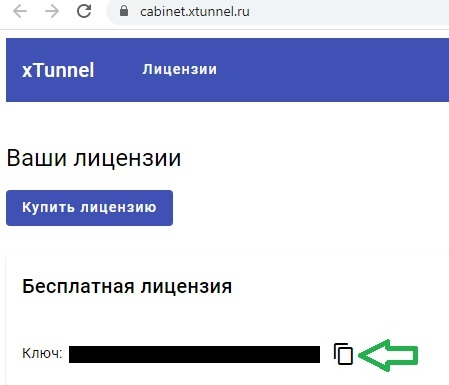

Нажмите на значок ключа (1) на левой панели меню коллаба, вставьте скопированный секретный ключ API в ячейку (4), впишите название ключа XTUNNEL_API_KEY в ячейку (3) и разрешите доступ к этому ключу (2)

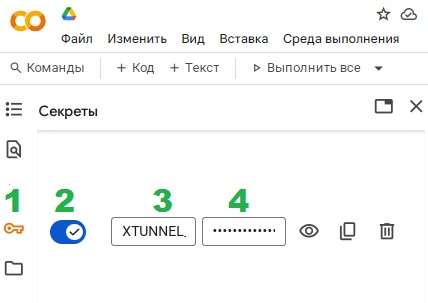

In [13]:
# Т.к. я использую bore мне нет необходимости подгружать ключи в переменные окружения, он не требует API-key

# import os
# Для запуска из Colab
# from google.colab import userdata
# os.environ["XTUNNEL_API_KEY"]=userdata.get('XTUNNEL_API_KEY') #<- пароли в коде не храним

# Для локального запуска из Jupyter
# with open("key.txt") as f:
    # os.environ["XTUNNEL_API_KEY"] = f.readline()

In [14]:
# Получаем туннель
# Ссылка из задания не работала, пришлось искать альтернативы
# !wget -O xt.tar.gz https://dl.xtunnel.ru/v2.3.0/xtunnel-v2.3.0-linux-x64.tar.gz

# Распаковываем архив
# !tar -xzf xt.tar.gz

# Присваиваем права
# !chmod +x ./xtunnel

# Даём API ключ туннелю
# !./xtunnel register $XTUNNEL_API_KEY > /dev/null 2>&1

In [15]:
# Установка bore как альтернатива xtunnel, поскольку xtunnel падает сегой
# bore не требует ключей, но имеет незащищенное подключение, антивирь может ругаться
!wget -qO bore https://github.com/ekzhang/bore/releases/download/v0.5.0/bore-v0.5.0-x86_64-unknown-linux-musl.tar.gz
!tar -xzf bore
!chmod +x bore

In [16]:
# Получаем пакеты в хост-окружение Python
!pip install fastapi uvicorn scalar_doc nest_asyncio -qqq

In [17]:
%%writefile app.py
# Записали ячейку в app.py для запуска из консоли
import pandas as pd
import datetime
from pydantic import BaseModel, Field
from fastapi import FastAPI, HTTPException, Request, Response
from scalar_doc import ScalarConfiguration, ScalarDoc
import xml.etree.ElementTree as ET
import nest_asyncio
import re
nest_asyncio.apply()

# Инициализируем начальные данные для добавления в файл `app.py`
df = pd.DataFrame([
    ['Антифриз EURO G11 (-45°С) зеленый, силикатный 5кг', 1025, 329, 11, 'c', 'антифриз', datetime.datetime(2026, 10, 16, 12, 36, 22)],
    ['Антифриз готовый фиолетовый Синтек MULTIFREEZE 5кг', 250, 315, 38, 'b', 'антифриз', datetime.datetime(2025, 12, 11, 8, 25, 31)],
    ['Антифриз G11 зеленый', 120, 329, 61, 'b', 'антифриз', datetime.datetime(2025, 6, 15, 15, 36, 30)],
    ['Антифриз Antifreeze OEM China OAT red -40 5кг', 390, 504, 65, 'c', 'антифриз', datetime.datetime(2025, 11, 30, 4, 12, 39)],
    ['Антифриз G11 зеленый', 135, 407, 93, 'b', 'антифриз', datetime.datetime(2026, 8, 25, 3, 24, 1)],
])

df.columns = ['Наименование товара', 'Цена, руб.', 'cpm', 'Скидка', 'tp', 'Категория', 'dt']
df['Год'] = df['dt'].dt.year
df=df.drop(['cpm',  'tp', 'dt'],axis=1)

# Преобразовываю pd.DataFrame в словарь id: items
items_db = {str(k): v for k, v in df.to_dict(orient="index").items()}

# Преобразовываю словарь в словарь id: {id + **items}
for id, item in items_db.items():
    items_db[id] = dict(id = id, **item)

# Инициализирую следующий id товара
next_id = len(items_db)

# Для добавления нового элемента в базу по соответствующему ключу
class ItemCreate(BaseModel):
    НаименованиеТовара: str = Field(..., alias="Наименование товара")
    ЦенаРуб: float = Field(..., alias="Цена, руб.")
    Скидка: int
    Категория: str
    Год: int

    # Для добавления нового элемента в базу как по имени, так и по алиасу
    class Config:
        populate_by_name = True

# Для вывода из базы элемента как по алиасу, так и по имени элемента
class ItemResponse(BaseModel):
    НаименованиеТовара: str = Field(..., alias="Наименование товара")
    ЦенаРуб: float = Field(..., alias="Цена, руб.")
    Скидка: int
    Категория: str
    Год: int

    class Config:
        populate_by_name = True

# Вспомогательные функции для XML
def clean_xml_key(key: str) -> str:
    # Для преобразования ключей словаря в безопасные, чтоб ничего не крашнулось
    return re.sub(r'[^a-zA-Z0-9а-яА-Я_-]', '_', key)

def dict_to_xml(item: dict, root_tag: str = "item") -> str:
    # Преобразует `items_db` словарь в XML вид
    root = ET.Element(root_tag)
    for key, value in item.items():
        safe_key = clean_xml_key(key)
        elem = ET.SubElement(root, safe_key)
        elem.text = str(value)
    return ET.tostring(root, encoding='unicode')

def items_to_xml(items: list[dict]) -> str:
    # Преобразует элемент/позицию в словаре `items_db` в XML вид
    root = ET.Element("items")
    for item in items:
        root.append(ET.fromstring(dict_to_xml(item, "item")))
    return ET.tostring(root, encoding='unicode', xml_declaration=True)

# Описание FastAPI приложения
DESCRIPTION = """
# API управления товарами (постами)

Данный сервис предоставляет REST API для управления товарами (или постами).
Поддерживаются форматы **JSON** и **XML** в зависимости от заголовка `Accept`.

## Основные возможности

- **Получение списка всех товаров**
  `GET /items`
  Возвращает массив товаров.
  *Пример:* `Accept: application/json` → JSON, `Accept: application/xml` → XML.

- **Получение одного товара по ID**
  `GET /items/{id}`
  Возвращает товар с указанным строковым идентификатором.

- **Создание нового товара**
  `POST /items`
  Принимает JSON с полями:
  - `Наименование товара` (строка)
  - `Цена, руб.` (число)
  - `Скидка` (целое)
  - `Категория` (строка)
  - `Год` (целое)

  Возвращает созданный объект (без поля `id`).

## Форматы ответов

- **JSON** — возвращается по умолчанию или при `Accept: application/json`.
- **XML** — возвращается при `Accept: application/xml`.
  В XML все недопустимые символы в именах тегов заменяются на подчёркивания для корректного отображения.

## Документация

- `/docs` — интерактивная документация (Scalar).
- `/docs2` — альтернативная документация (Scalar).

## Примеры

**Создание товара:**
```json
POST /items
{
  "Наименование товара": "Антифриз G12 красный",
  "Цена, руб.": 750,
  "Скидка": 15,
  "Категория": "антифриз",
  "Год": 2026
  "id": 2
}
```

**Получение в XML:**
``` Bash
curl -H "Accept: application/xml" http://localhost:8000/items
```

"""

app = FastAPI(title="Test", description=DESCRIPTION, docs_url=None, redoc_url=None)
docs = ScalarDoc.from_spec(spec=app.openapi_url, mode="url")

@app.post("/foo")
def post_foo(a: str):
    return a + " - ok"

@app.get("/items")
def get_items(request: Request):
    accept = request.headers.get("Accept", "")
    items_list = list(items_db.values())
    if "application/xml" in accept:
        # Проверяем хэдэр и преобазуем в XML если есть такой параметр
        return Response(content=items_to_xml(items_list), media_type="application/xml")
    return items_list

@app.get("/items/{item_id}")
def get_item(item_id: str, request: Request):
    item = items_db.get(item_id)
    if not item:
        raise HTTPException(status_code=404, detail="Item not found")
    accept = request.headers.get("Accept", "")
    # Проверяем хэдэр и преобазуем в XML если есть такой параметр
    if "application/xml" in accept:
        return Response(content=dict_to_xml(item, "item"), media_type="application/xml")
    return item

@app.post("/items", status_code=201)
def post_item(item: ItemCreate, request: Request):
    global next_id
    # Определим next_id как максимальный существующий ключ + 1,
    # поскольку порядок ключей может быть произвольным, а не только лишь по длине базы
    new_id = str(next_id)
    data = dict(id = new_id, **item.dict(by_alias=True))
    items_db[new_id] = data
    next_id += 1
    return data

@app.get("/docs", include_in_schema=False)
def get_docs():
    # Эндпоинт документации
    docs_html = docs.to_html()
    return Response(content=docs_html, media_type="text/html")

@app.get("/docs2", include_in_schema=False)
def get_docs2():
    # Эндпоинт документации 2
    docs = ScalarDoc.from_spec("http://localhost/openapi.json", mode="url")
    docs.set_title("Автодокументация")
    docs.set_configuration(ScalarConfiguration())
    docs_html = docs.to_html()
    return Response(docs_html, media_type="text/html")

Writing app.py


In [ ]:
print("Скопируйте адрес, например `bore.pub:27278`, " +
      "вставьте его в адресную строку браузера, добавьте /docs, нажмите Enter")
print("Антивирус может блокировать переход по ссылке, " +
      "любые переходы на ваш страх и риск")

# запуотск bash команд для поднятия сервера
!sleep 5 & uvicorn app:app --host localhost --port 8002 --loop asyncio & ./bore local 8002 --to bore.pub & wait

Скопируйте адрес, например `bore.pub:27278`, вставьте его в адресную строку браузера, добавьте /docs, нажмите Enter
Антивирус может блокировать переход по ссылке, любые переходы на ваш страх и риск
2026-03-29T18:57:55.358909Z  INFO bore_cli::client: connected to server remote_port=17805
2026-03-29T18:57:55.358957Z  INFO bore_cli::client: listening at bore.pub:17805
INFO:     Started server process [402]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
INFO:     Uvicorn running on http://localhost:8002 (Press CTRL+C to quit)
2026-03-29T18:58:39.871258Z  INFO proxy{id=b8da21c9-9840-4df8-907a-ce55a09463cb}: bore_cli::client: new connection
2026-03-29T18:58:39.941994Z  INFO proxy{id=b2582659-2076-41db-a929-edd123b753e7}: bore_cli::client: new connection
INFO:     ::1:60800 - "GET /docs HTTP/1.1" 200 OK
INFO:     ::1:60800 - "GET /None HTTP/1.1" 404 Not Found
INFO:     ::1:60800 - "GET /docs HTTP/1.1" 200 OK
INFO:     ::1:60800 - "GET /openapi.json HTTP/1.1

%%html
Сразу тестируйте свой код

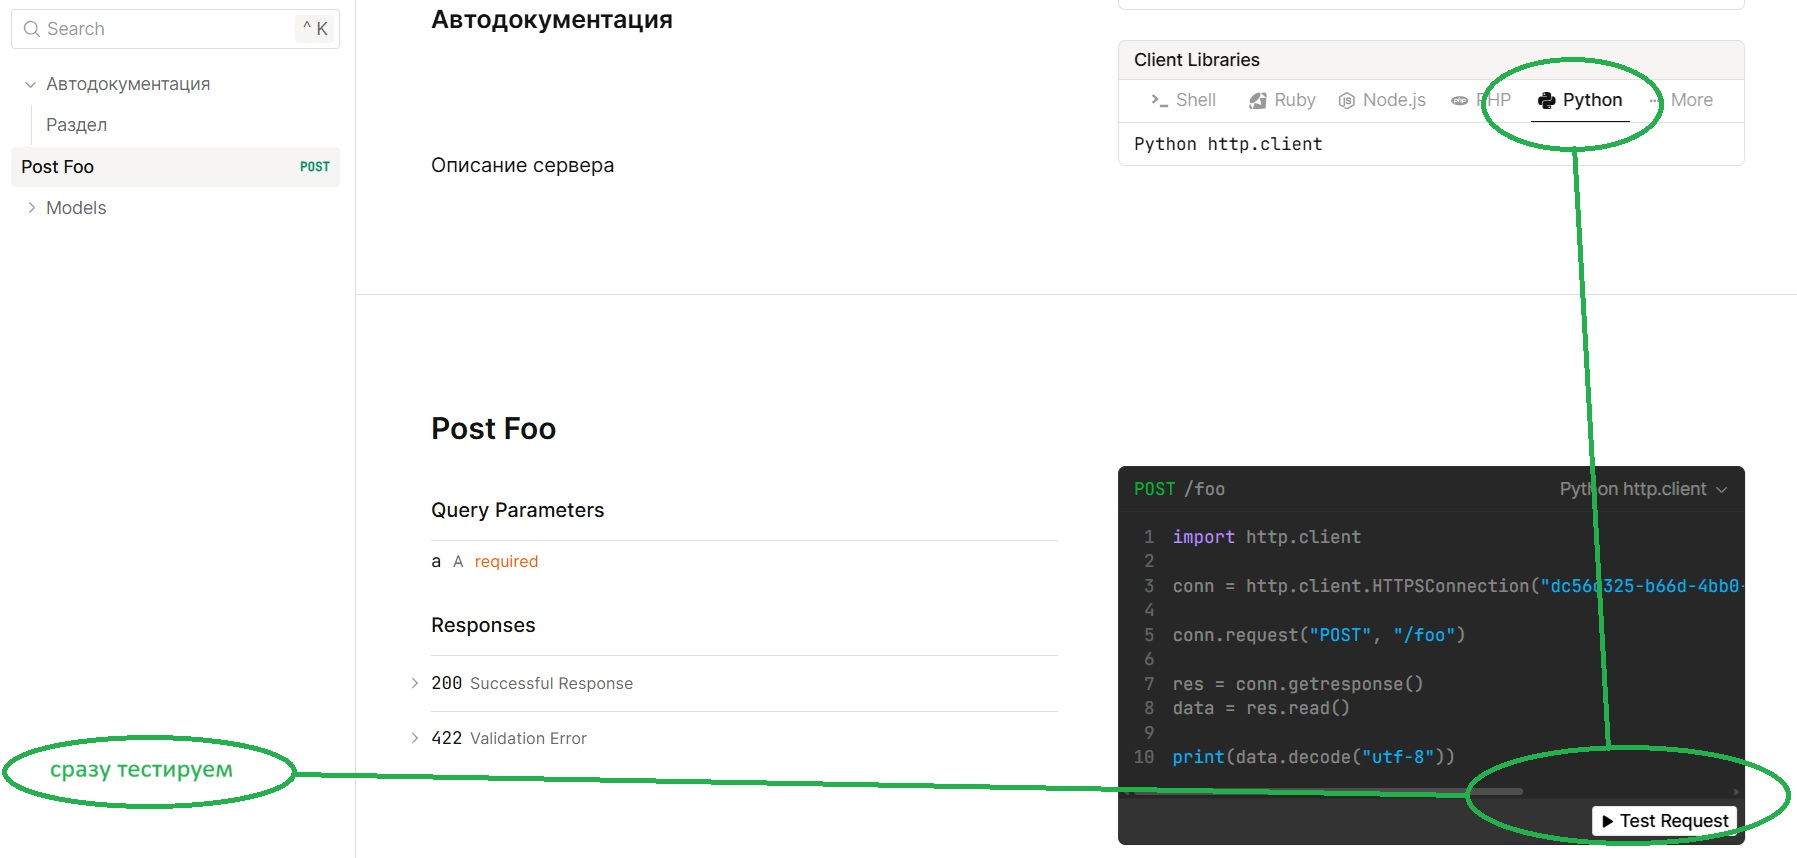

#### Итоги тестов

> GET items  
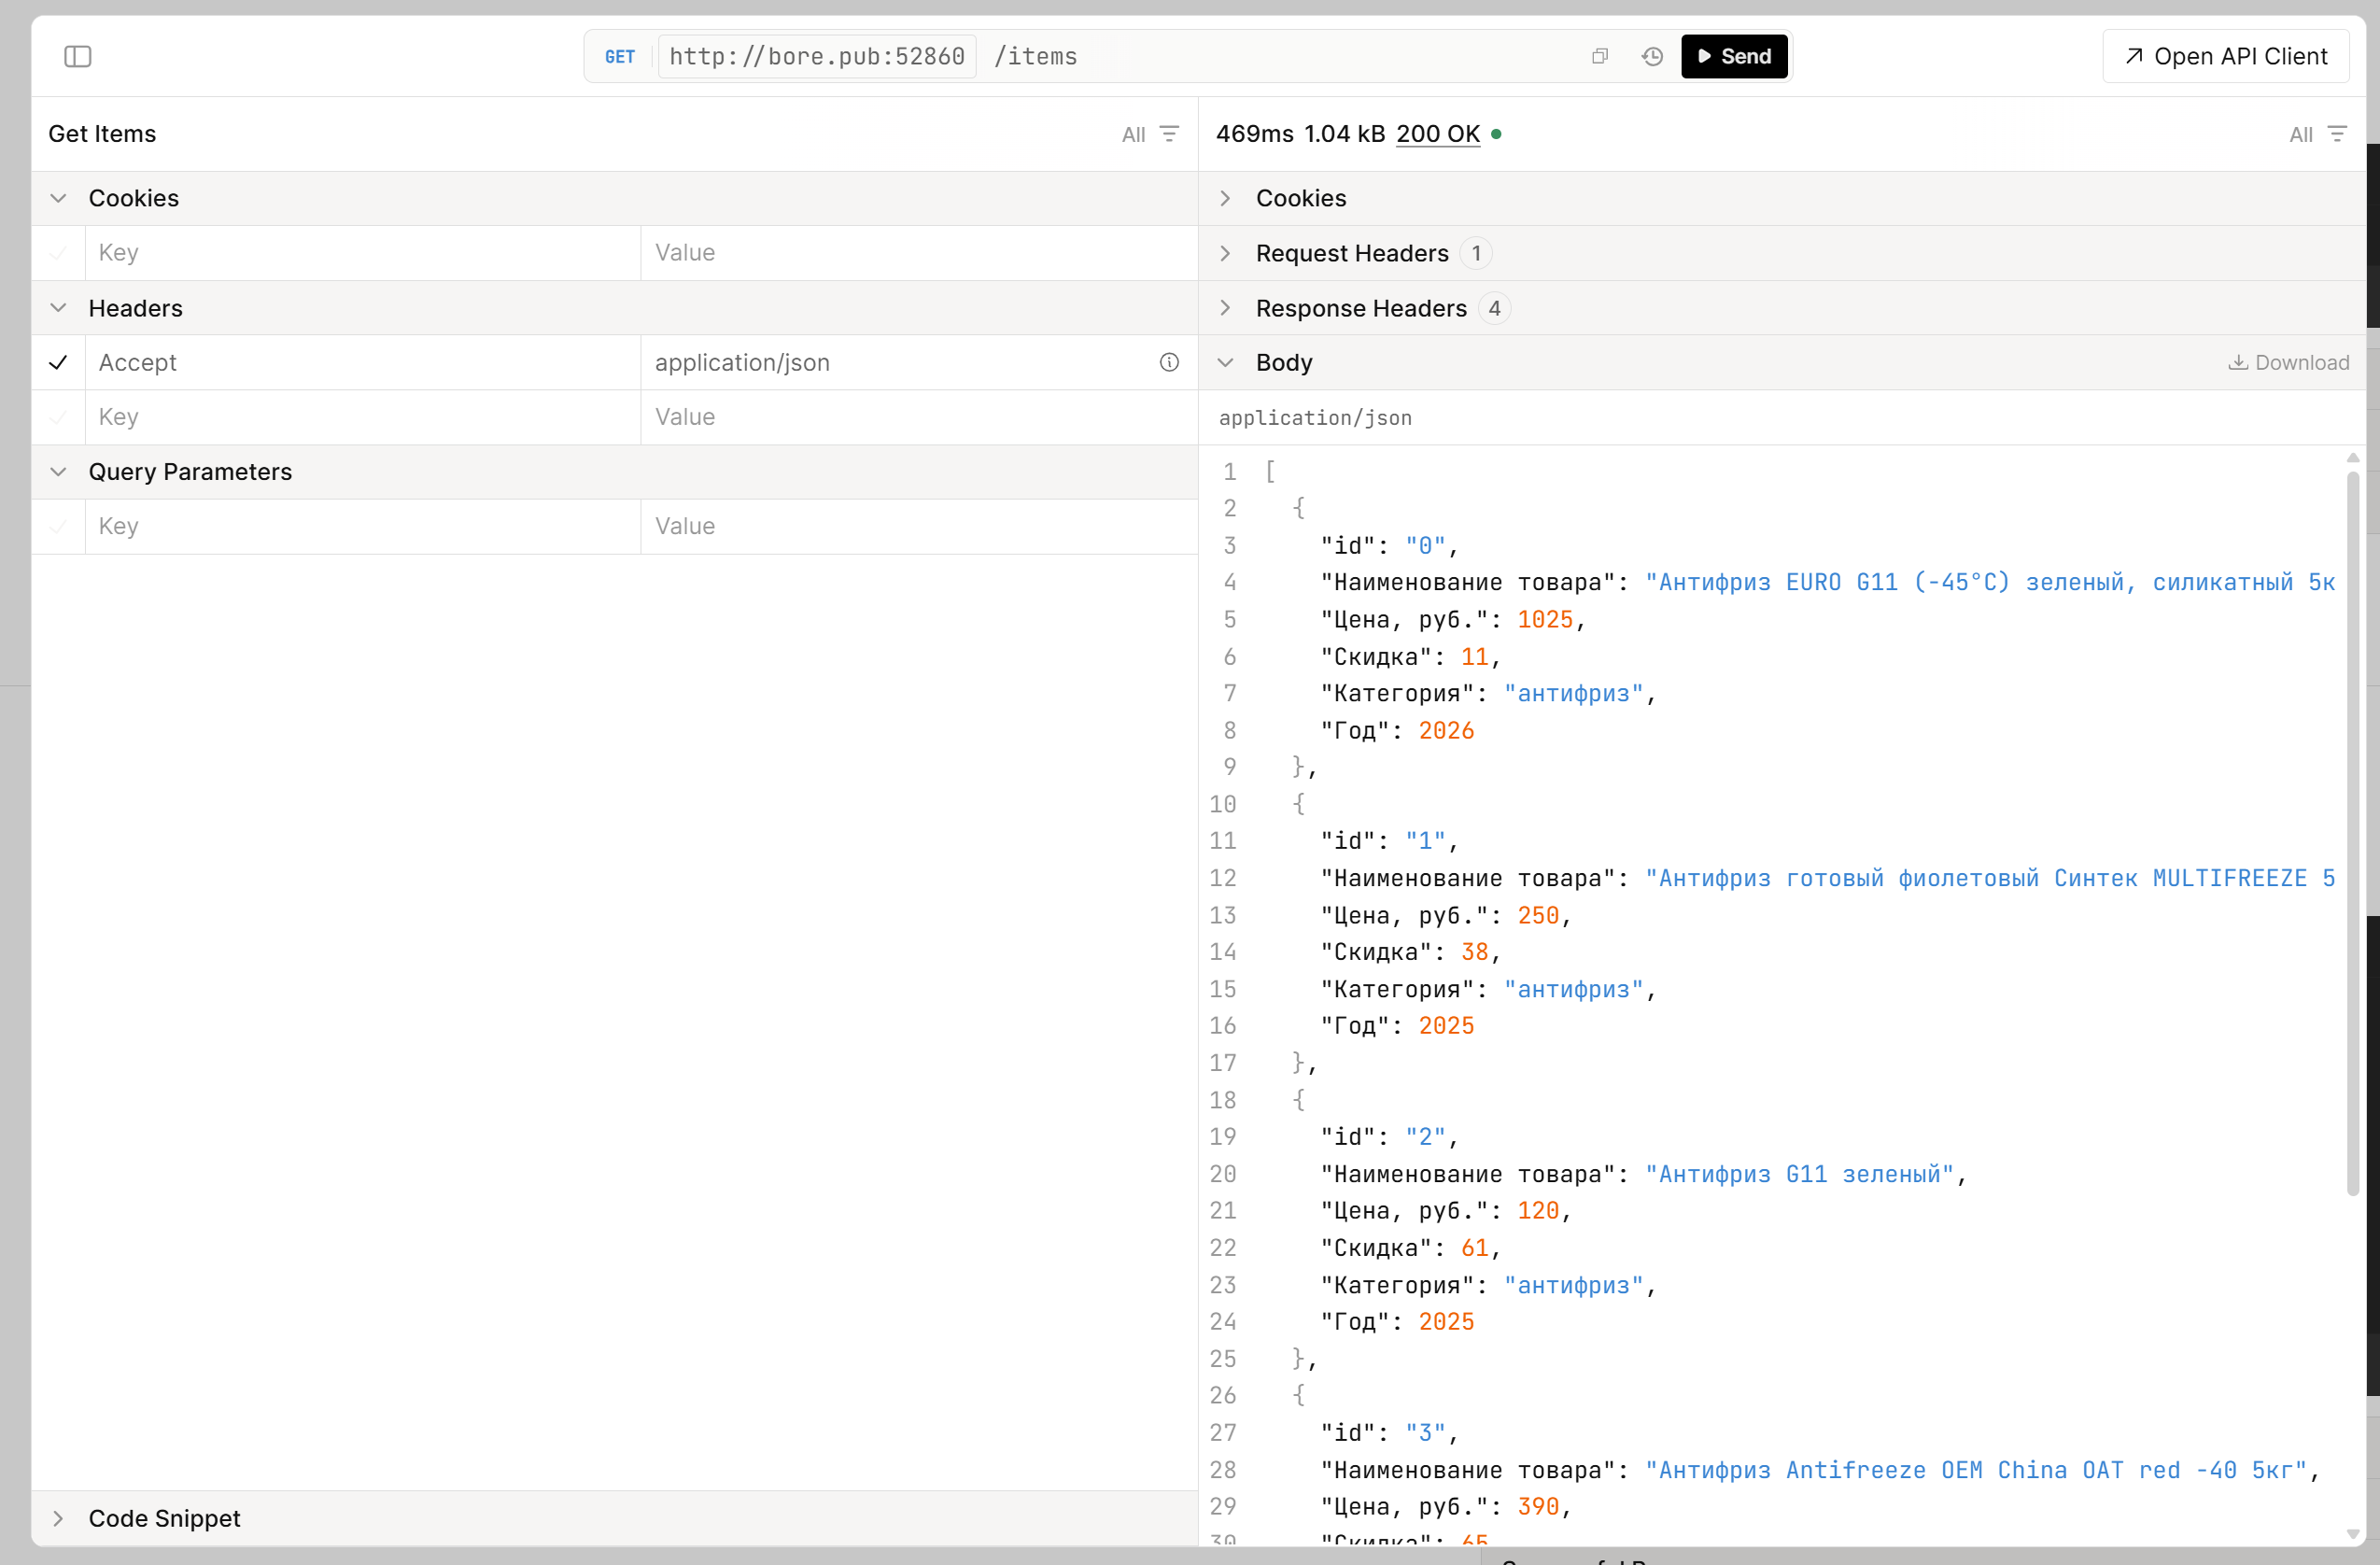
> GET item  
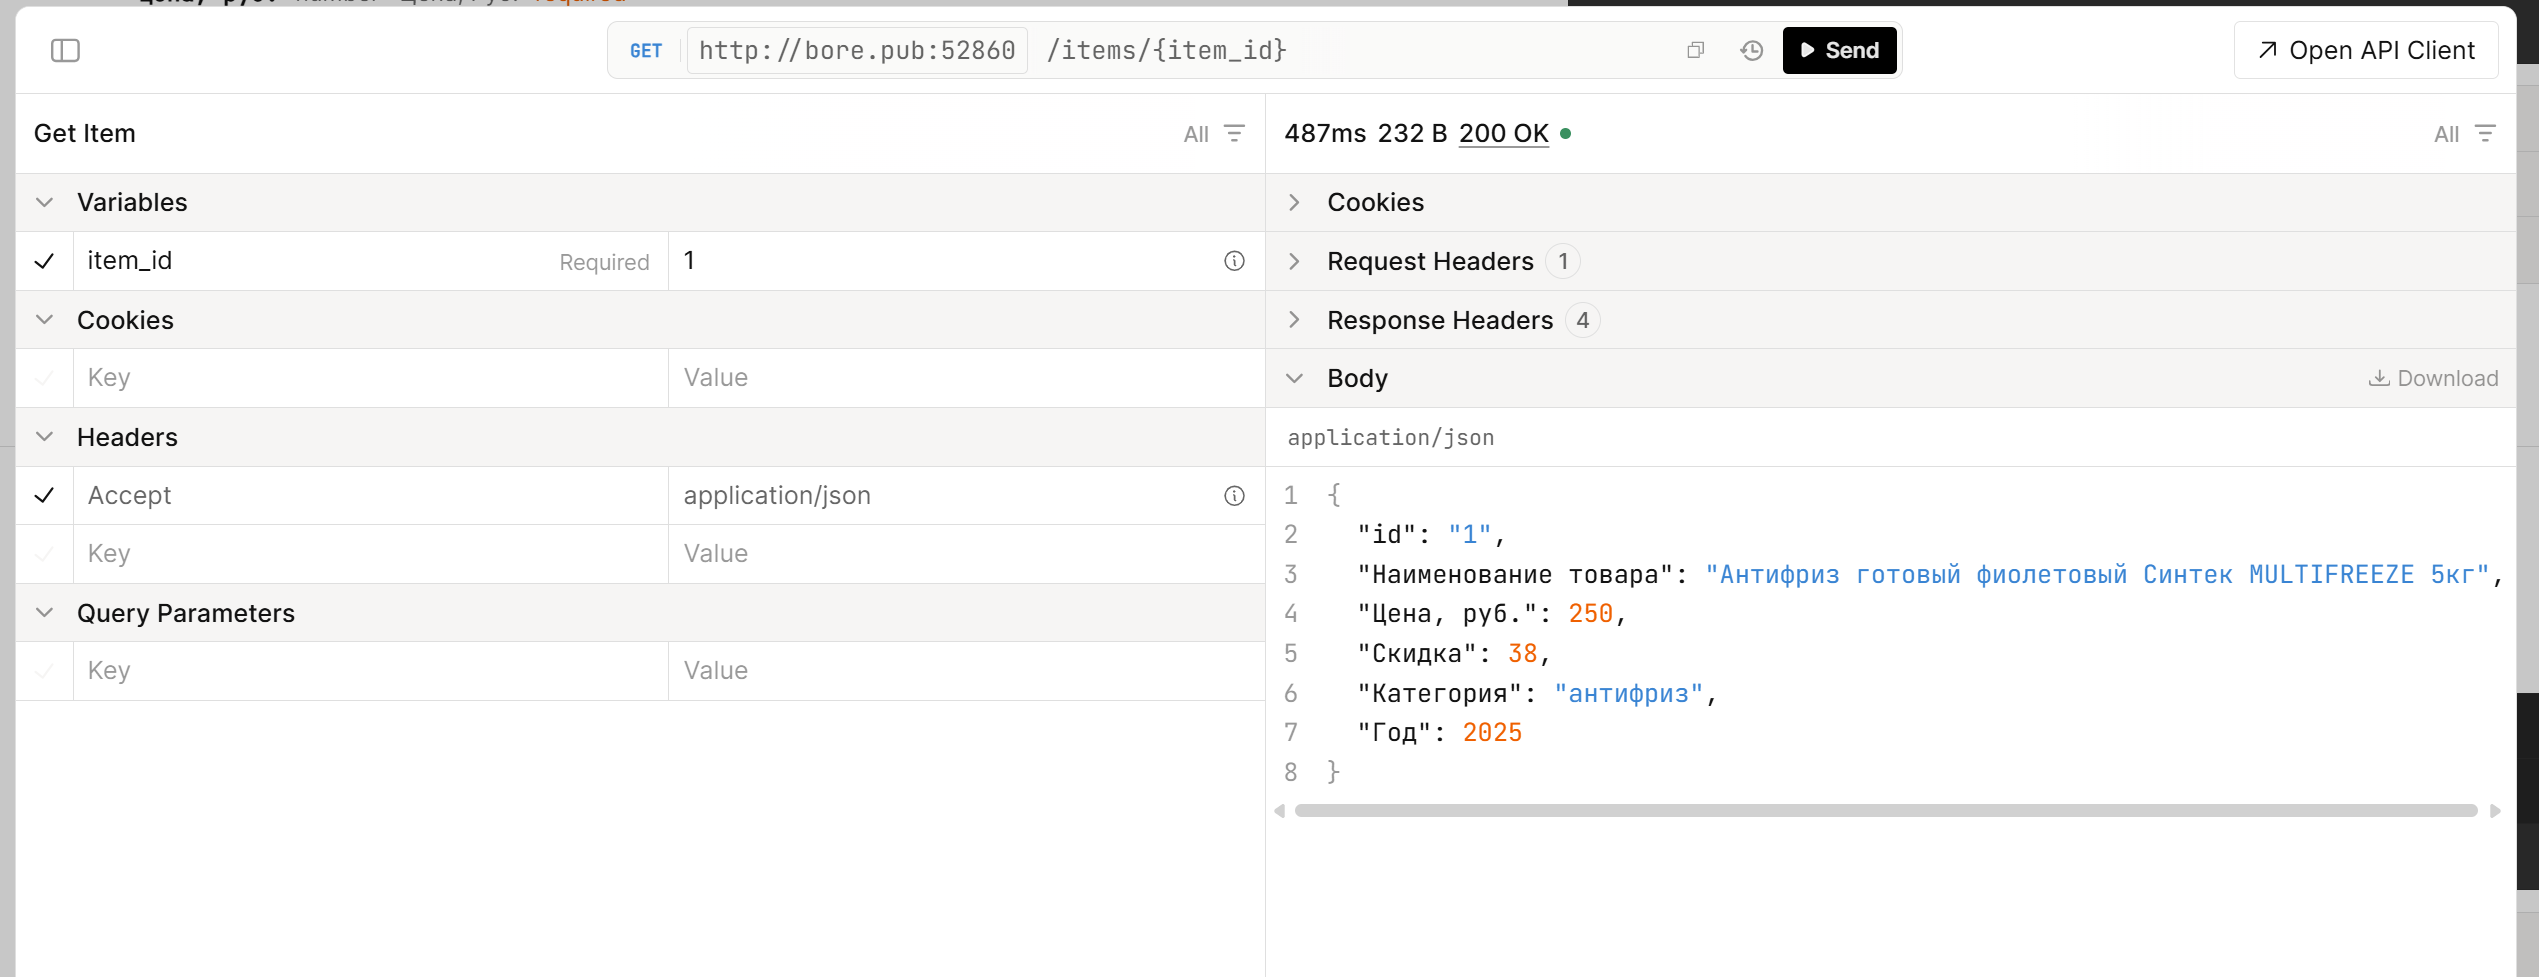
> POST item  
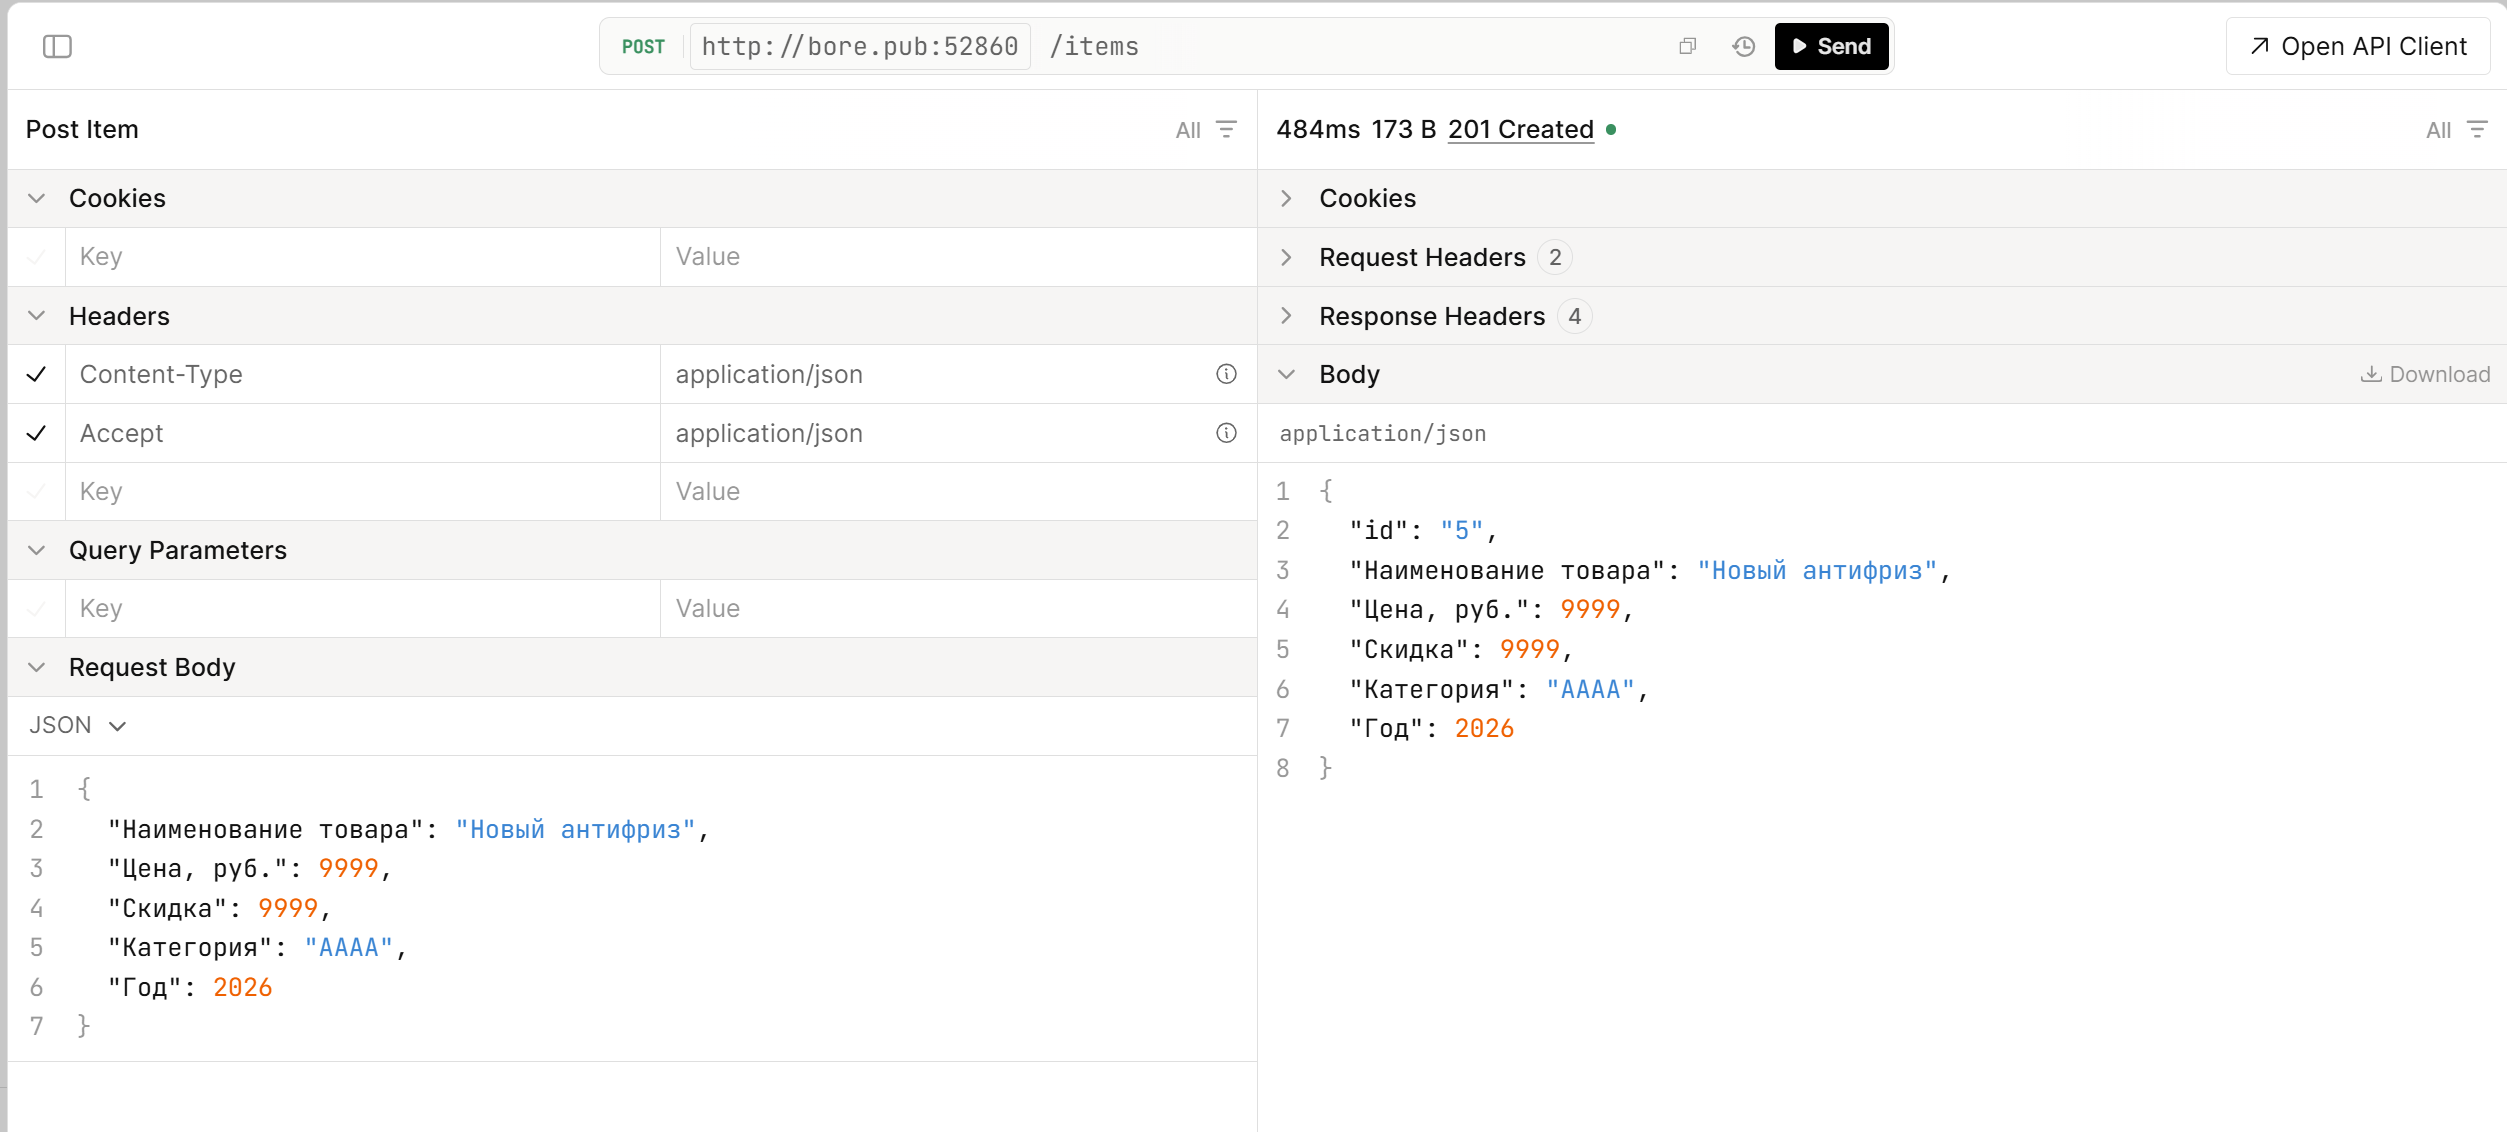
> GET new item  
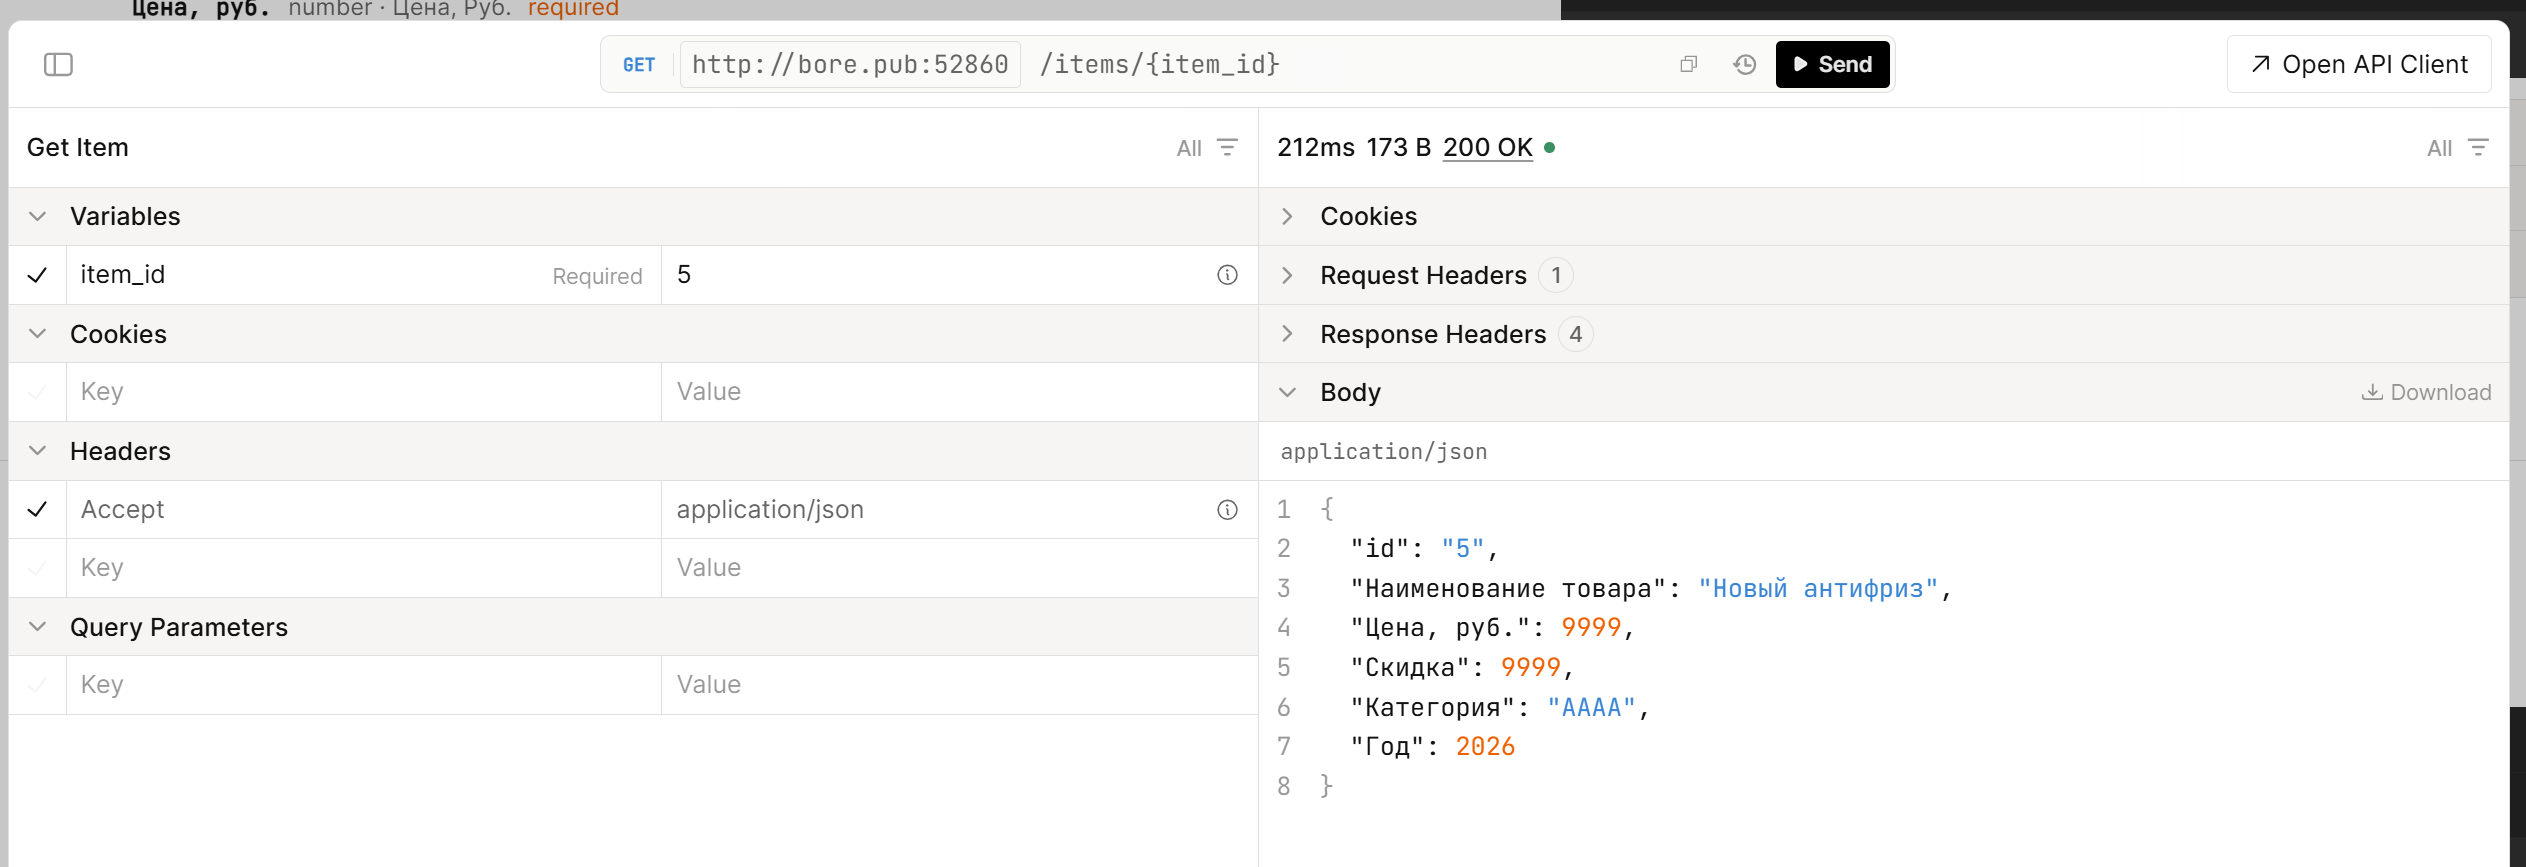
> GET XML  
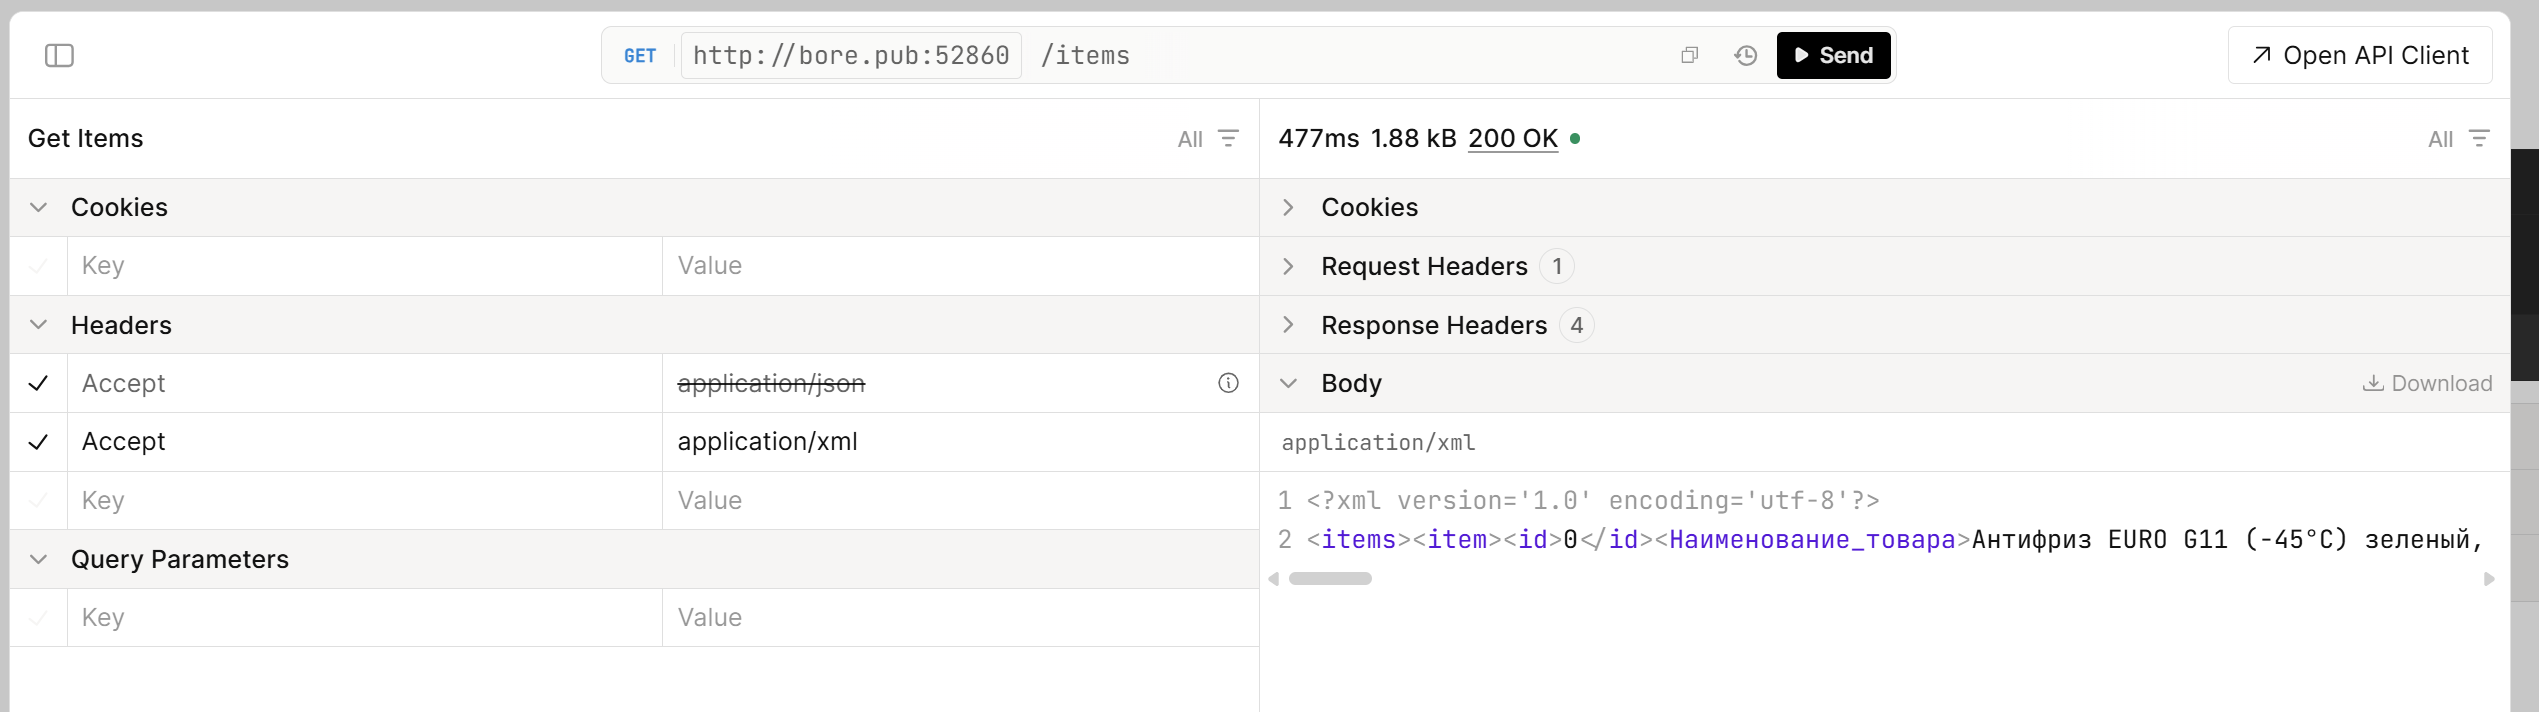

## Итоговое оформление


1. Проверьте, что ноутбук запускается.  
2. Сформулируйте ниже 5–8 выводов, когда стоит применять подход code-first и почему чаще стоит придерживаться подхода API-first.  



> Выводы:  
Чтобы разобраться с Заданием 5 я потратил целые сутки, но оно того стоило. Задание непонятное, но очень крутое, спасибо! Я осознал, какие ошибки я сделал в заданиях 1-4 и исправил их.  
Как понял: при сборке FastAPI многое из того, что я просто перетянул из 1 - 4 работало вообще не корректно

Файл app.py я сохранил и запушил задание в [свой репо на GitHub](https://github.com/EgrSlv/MLOps__MIPT)

Что я понял + немного общедоступной информации:

По __API-first__:
1. __API-first__ обеспечивает контракт до реализации - позволяет согласовать интерфейс с потребителями (фронтенд, мобильные приложения, другие сервисы) ещё до написания кода, снижая количество переделок.  
1. Автоматическая генерация документации и клиентов - при __API-first__ (например, через OpenAPI/Swagger) можно сразу получить интерактивную документацию, сгенерировать клиентские SDK и даже мок-серверы, ускоряя параллельную разработку.  
1. __API-first__ способствует дисциплине версионирования - явное описание эндпоинтов, полей и статусов помогает продумать обратную совместимость и избежать breaking changes, которые при __Code-first__ могут возникать незаметно.  
1. При работе в команде __API-first__ снижает конфликты - чёткий контракт позволяет параллельно разрабатывать клиентскую и серверную части, тестировать интеграцию до завершения серверной реализации.
1. __API-first__ упрощает масштабирование и поддержку - наличие единой спецификации облегчает онбординг новых разработчиков, позволяет автоматизировать валидацию запросов и ответов, а также использовать инструменты мониторинга соответствия спецификации.

По __Code-first__:
1. __Code-first__ удобен для прототипирования - если нужно быстро проверить гипотезу или сделать внутренний инструмент, проще написать код и уже потом (при необходимости) добавить спецификацию. Но для долгоживущих сервисов это часто ведёт к рассинхронизации документации и реального поведения.
1. __Code-first__ оправдан, когда API является вторичным интерфейсом - например, внутренний сервис с единственным потребителем, где изменения легко синхронизировать, или при использовании фреймворков с автоматической генерацией OpenAPI из кода (FastAPI, NestJS), что сочетает преимущества обоих подходов.
1. В академических и исследовательских проектах чаще уместен __Code-first__ - здесь важнее быстро проверить алгоритмы (например, модели ML), а API - лишь обёртка. Но если проект перерастает в продакшен, стоит добавить спецификацию, переходя к __API-first__.


Итог: __API-first__ - предпочтительный подход для большинства промышленных проектов, так как он ставит контракт во главу угла, повышает надёжность и удобство интеграции. __Code-first__ остаётся инструментом для быстрых прототипов и ситуаций, когда API является вторичным по отношению к основной логике.

## Примечание

Сохраните код работоспособного сервера из [ячейки](#scrollTo=EQRTmZPa2hi1).

Этот сервис пригодится для создания контейнеризированного приложения в ДЗ 4.